In [1]:
import os, sys
os.chdir(os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))  # ensure project root
sys.path.insert(0, os.getcwd())
from src import model
import pandas as pd
import numpy as np
import gurobipy
import os
from matplotlib import pyplot as plt

In [2]:
%%capture
diesel_price=0.12
emissions_cap=1000
network=model.main(emissions_cap,diesel_price)

saving model for later comparison

In [3]:
os.makedirs("models_with_existing_optimized",exist_ok=True)
models_path="models_with_existing_optimized/base_case.nc"
network.export_to_netcdf(models_path)
print(f"Model saved to {models_path}")
network.links

Model saved to models_with_existing_optimized/base_case.nc


attribute,bus0,bus1,type,carrier,efficiency,build_year,lifetime,p_nom,p_nom_extendable,p_nom_min,...,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,p_nom_opt,bus2,efficiency2
Link,,,,,,,,,,,,,,,,,,,,,
GenSet,diesel bus,AC bus,,diesel,0.40,0,inf,0.0,True,0.0,...,0,1,0,NaN,NaN,1.0,1.0,263.450420,heat bus,0.20
charge,AC bus,battery bus,,AC,0.98,0,inf,0.0,True,0.0,...,0,1,0,NaN,NaN,1.0,1.0,17162.583689,,1.00
discharge,battery bus,AC bus,,AC,1.00,0,inf,0.0,True,0.0,...,0,1,0,NaN,NaN,1.0,1.0,17162.978049,,1.00
electrolysis,AC bus,hydrogen bus,,hydrogen,0.60,0,inf,0.0,True,0.0,...,0,1,0,NaN,NaN,1.0,1.0,0.000000,,1.00
fuel cell,hydrogen bus,AC bus,,hydrogen,0.60,0,inf,0.0,True,0.0,...,0,1,0,NaN,NaN,1.0,1.0,0.000000,heat bus,0.32
Boiler,AC bus,heat bus,,AC,0.90,0,inf,0.0,True,0.0,...,0,1,0,NaN,NaN,1.0,1.0,0.000000,,1.00
Geothermal heat pump,AC bus,heat bus,,AC,4.00,0,inf,0.0,True,0.0,...,0,1,0,NaN,NaN,1.0,1.0,7.099047,,1.00
Boiler - existing,AC bus,heat bus,,AC,0.90,0,inf,128.0,False,0.0,...,0,1,0,NaN,NaN,1.0,1.0,128.000000,,1.00


In [4]:
discount_rate=0.06
generators = network.generators
generators_t = network.generators_t

In [5]:
marginal_diesel= (generators.loc["Diesel_import-existing"]["marginal_cost"]*(generators_t.p.sum().loc["Diesel_import-existing"]))/(1+discount_rate)
capital_diesel=(generators.loc["Diesel_import-existing"]["capital_cost"]*generators.p_nom_opt.loc["Diesel_import-existing"])/(1+discount_rate)
annual_cost_diesel=capital_diesel+marginal_diesel
LCOE_diesel=annual_cost_diesel/((generators_t.p.sum().loc["Diesel_import-existing"])*(1+discount_rate))
print(marginal_diesel)
print(capital_diesel)
print(LCOE_diesel)

17914.078657580976
23539.377877092786
0.2471358719408006


In [6]:
capital_PV_roof=generators.loc["PV roof - existing"]["capital_cost"]*generators.p_nom_opt.loc["PV roof - existing"]
print(capital_PV_roof)
annual_cost_PV_roof=capital_PV_roof
LCOE_PV_roof=annual_cost_PV_roof/((generators_t.p.sum().loc["PV roof - existing"])*(1+discount_rate))
print(LCOE_PV_roof)

25420.219999999998
0.6229679826447606


In [7]:
capital_PV_park=generators.loc["PV park - existing"]["capital_cost"]*generators.p_nom_opt.loc["PV park - existing"]
annual_cost_PV_park=capital_PV_park
LCOE_PV_park=annual_cost_PV_park/((generators_t.p.sum().loc["PV park - existing"])*(1+discount_rate))
print(LCOE_PV_park)

0.4617227549399195


In [8]:
marginal_wind=(generators.loc["SWP turbine"])
capital_wind=generators.loc["SWP turbine"]["capital_cost"]*generators.p_nom_opt.loc["SWP turbine"]
LCOE_wind=capital_wind/(((generators_t.p.sum().loc["SWP turbine"])*(1+discount_rate)))
print(LCOE_wind)

0.10696487150743357


In [23]:
network.links

attribute,bus0,bus1,type,carrier,efficiency,build_year,lifetime,p_nom,p_nom_extendable,p_nom_min,...,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,p_nom_opt,bus2,efficiency2
Link,,,,,,,,,,,,,,,,,,,,,
GenSet,diesel bus,AC bus,,diesel,0.40,0,inf,0.0,True,0.0,...,0,1,0,NaN,NaN,1.0,1.0,263.450420,heat bus,0.20
charge,AC bus,battery bus,,AC,0.98,0,inf,0.0,True,0.0,...,0,1,0,NaN,NaN,1.0,1.0,17162.583689,,1.00
discharge,battery bus,AC bus,,AC,1.00,0,inf,0.0,True,0.0,...,0,1,0,NaN,NaN,1.0,1.0,17162.978049,,1.00
electrolysis,AC bus,hydrogen bus,,hydrogen,0.60,0,inf,0.0,True,0.0,...,0,1,0,NaN,NaN,1.0,1.0,0.000000,,1.00
fuel cell,hydrogen bus,AC bus,,hydrogen,0.60,0,inf,0.0,True,0.0,...,0,1,0,NaN,NaN,1.0,1.0,0.000000,heat bus,0.32
Boiler,AC bus,heat bus,,AC,0.90,0,inf,0.0,True,0.0,...,0,1,0,NaN,NaN,1.0,1.0,0.000000,,1.00
Geothermal heat pump,AC bus,heat bus,,AC,4.00,0,inf,0.0,True,0.0,...,0,1,0,NaN,NaN,1.0,1.0,7.099047,,1.00
Boiler - existing,AC bus,heat bus,,AC,0.90,0,inf,128.0,False,0.0,...,0,1,0,NaN,NaN,1.0,1.0,128.000000,,1.00


total_LCOE

In [24]:
total_annualized_cost = annual_cost_diesel+annual_cost_PV_roof+annual_cost_PV_park+capital_wind
total_energy_produced = network.generators_t.p.sum().sum()
print(total_annualized_cost)
print(total_energy_produced)

for storage in network.stores.index:
    storage_annualized_capex = network.stores.at[storage, 'capital_cost'] * network.stores.at[storage, 'e_nom']
    total_annualized_cost += storage_annualized_capex

for links in network.links.index:
    links_annualized_capex = network.links.at[links, 'capital_cost'] * network.links.at[links, 'p_nom_opt']
    total_annualized_cost+=links_annualized_capex
    print("links:",links_annualized_capex)

if total_energy_produced > 0:
    overall_lcoe = total_annualized_cost / total_energy_produced
else:
    overall_lcoe = float('inf')  # Handle the case where no energy is produced

print(f"Overall LCOE of the system including all components: {overall_lcoe:.2f} €/MWh")


163949.6355418639
577655.1340129446
links: 0.0
links: 0.0
links: 0.0
links: 0.0
links: 0.0
links: 0.0
links: 2186.1284588296635
links: 1179.962329303698
Overall LCOE of the system including all components: 0.41 €/MWh


In [25]:
exchange_rate=11.92 #12.09
print("LCOE_diesel",LCOE_diesel*exchange_rate)
print("LCOE_PV_park",LCOE_PV_park*exchange_rate)
print("LCOE PV roof", LCOE_PV_roof*exchange_rate)
print("LCOE wind", LCOE_wind*exchange_rate)
print("LCOE total", overall_lcoe*exchange_rate)
network.objective*exchange_rate

LCOE_diesel 2.9458595935343435
LCOE_PV_park 5.5037352388838405
LCOE PV roof 7.425778353125547
LCOE wind 1.2750212683686082
LCOE total 4.940243990066739


573556.2377505394

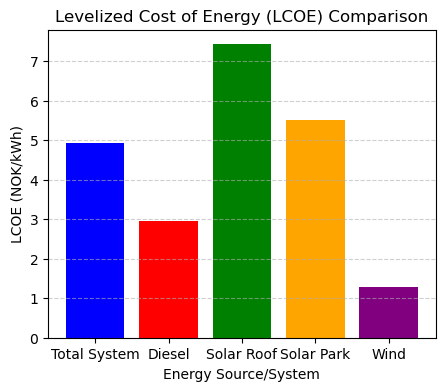

In [26]:
exchange_rate=11.92 #12.09
lcoe_data={'Total System': overall_lcoe*exchange_rate,  # in $/MWh
    'Diesel': LCOE_diesel*exchange_rate,        # in $/MWh
    'Solar Roof':LCOE_PV_roof*exchange_rate,
    'Solar Park':LCOE_PV_park*exchange_rate,
    'Wind':LCOE_wind*exchange_rate}
plt.figure(figsize=(5, 4))
plt.bar(lcoe_data.keys(), lcoe_data.values(), color=['blue', 'red', 'green','orange','purple'])
plt.title('Levelized Cost of Energy (LCOE) Comparison')
plt.ylabel('LCOE (NOK/kWh)')
plt.xlabel('Energy Source/System')
plt.grid(axis='y', linestyle='--', alpha=0.6)